In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [3]:
df=pd.read_csv("cleaned_data.csv")

In [4]:
df.drop(['Unnamed: 0','day','month','year'],axis=1,inplace=True)

In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,29,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,26,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,25,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,27,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [6]:
df['Classes  ']=np.where(df['Classes  '].str.contains("not fire"),0,1)


In [7]:
df['Classes  '].value_counts()

Classes  
1    138
0    106
Name: count, dtype: int64

### independent feature or dependent feature

In [8]:
X=df.drop('FWI',axis=1)
y=df['FWI']

In [13]:
X,y

(     Temperature    RH    Ws  Rain   FFMC   DMC    DC  ISI   BUI  Classes    \
 0             29  57.0  18.0    0.0  65.7   3.4   7.6  1.3   3.4          0   
 1             29  61.0  13.0    1.3  64.4   4.1   7.6  1.0   3.9          0   
 2             26  82.0  22.0   13.1  47.1   2.5   7.1  0.3   2.7          0   
 3             25  89.0  13.0    2.5  28.6   1.3   6.9  0.0   1.7          0   
 4             27  77.0  16.0    0.0  64.8   3.0  14.2  1.2   3.9          0   
 ..           ...   ...   ...    ...   ...   ...   ...  ...   ...        ...   
 239           30  65.0  14.0    0.0  85.4  16.0  44.5  4.5  16.9          1   
 240           28  87.0  15.0    4.4  41.1   6.5   8.0  0.1   6.2          0   
 241           27  87.0  29.0    0.5  45.9   3.5   7.9  0.4   3.4          0   
 242           24  54.0  18.0    0.1  79.7   4.3  15.2  1.7   5.1          0   
 243           24  64.0  15.0    0.2  67.3   3.8  16.5  1.2   4.8          0   
 
      Region  
 0       0.0  
 1      

### train and  test split

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
X_train.shape,X_test.shape

((183, 11), (61, 11))

### feature selection based on correleation

<Axes: >

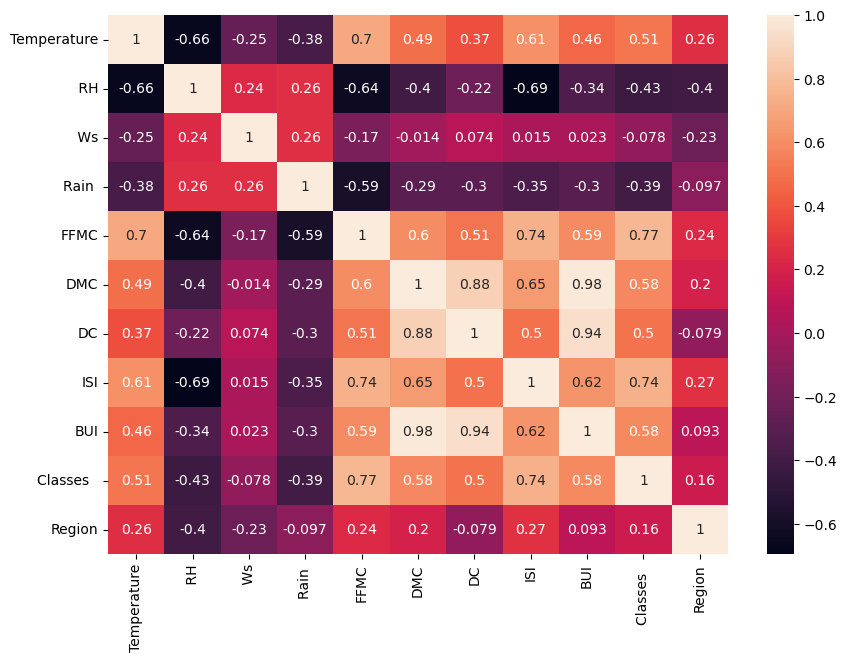

In [11]:
## check for multilineralty
plt.figure(figsize=(10,7))
corr=X_train.corr()
sns.heatmap(corr,annot=True)


In [12]:
def correlation(dataset,threshold):
    col_rel=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if(abs(corr_matrix.iloc[i][j]>threshold)):
                colname=corr_matrix.columns[i]
                col_rel.add(colname)
    return col_rel

In [13]:
correlation(df,0.85)

C:\Users\Anjali\AppData\Local\Temp\ipykernel_17996\1505847532.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if(abs(corr_matrix.iloc[i][j]>threshold)):


{'BUI', 'DC', 'FWI'}

In [14]:
X_train.drop(['BUI', 'DC'],axis=1,inplace=True)
X_test.drop(['BUI', 'DC'],axis=1,inplace=True)
X_train.shape,X_test.shape

((183, 9), (61, 9))

In [15]:
X_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
115,29,65.0,19.0,0.6,68.3,5.5,1.5,0,0.0
181,36,56.0,16.0,0.0,88.9,23.8,8.2,1,1.0
225,31,72.0,14.0,0.0,84.2,8.3,3.8,1,1.0
68,32,60.0,18.0,0.3,77.1,11.3,2.2,0,0.0
104,25,86.0,21.0,4.6,40.9,1.3,0.1,0,0.0


### feature standarilization

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)

#### compare btw scalling and not scaling and its effects on outlier and mean and variance

Text(0.5, 1.0, 'After scaling of X_train ')

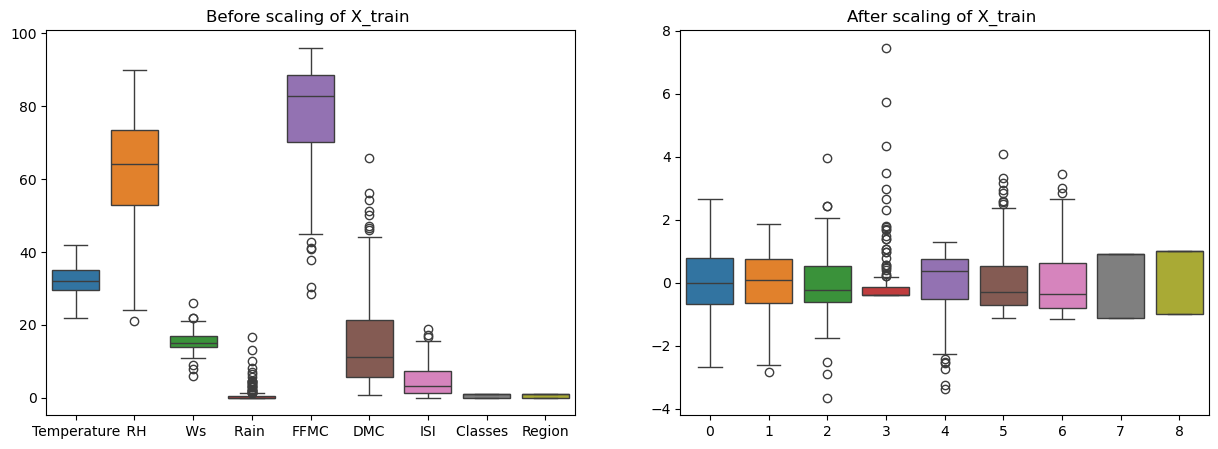

In [17]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("Before scaling of X_train ")
plt.subplot(1,2,2)
sns.boxplot(X_train_scale)
plt.title("After scaling of X_train ")

## model training 
#### linear regresssion

mean_absolut_error  0.5807379296658792
R2_score  0.9895827306215401


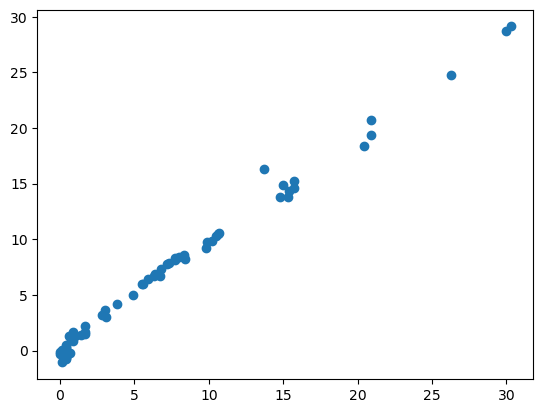

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score
linreg=LinearRegression()
linreg.fit(X_train_scale,y_train)
y_pred=linreg.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
plt.scatter(y_test,y_pred)
print("mean_absolut_error ",mae)
print("R2_score ",score)

#### lasso regression

mean_absolut_error  1.2053069952384183
R2_score  0.9512356962114603


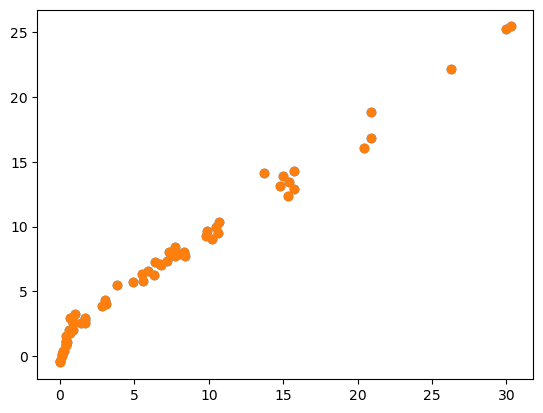

In [27]:
from sklearn.linear_model import Lasso
lassoo=Lasso()
lassoo.fit(X_train_scale,y_train)
y_pred=lassoo.predict(X_test_scale)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
plt.scatter(y_test,y_pred)
print("mean_absolut_error ",mae)
print("R2_score ",score)




### ridege regression

mean_absolut_error  0.6053972973991
R2_score  0.9888919408825259


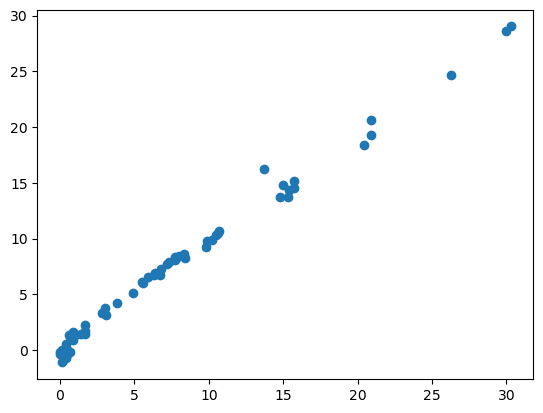

In [30]:
from sklearn.linear_model import Ridge
ridgee=Ridge()
ridgee.fit(X_train_scale,y_train)
y_pred=ridgee.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
plt.scatter(y_test,y_pred)
print("mean_absolut_error ",mae)
print("R2_score ",score)


#### ElasticNet regression

mean_absolut_error  1.9187332407071502
R2_score  0.8760325087536344


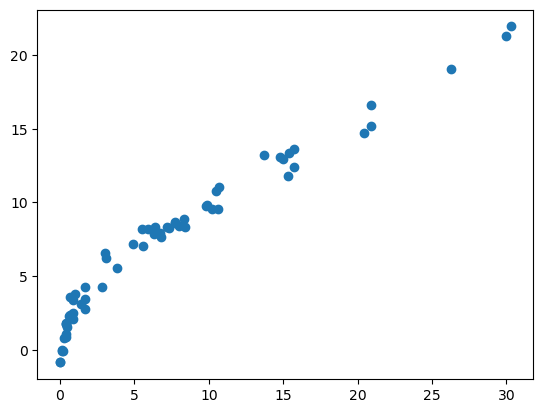

In [31]:
from sklearn.linear_model import ElasticNet
elastic=ElasticNet()
elastic.fit(X_train_scale,y_train)
y_pred=elastic.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
plt.scatter(y_test,y_pred)
print("mean_absolut_error ",mae)
print("R2_score ",score)

## HyperTunning

#### Lasso Cross Validation

mean_absolut_error  0.6161253622809278
R2_score  0.9888207998652048


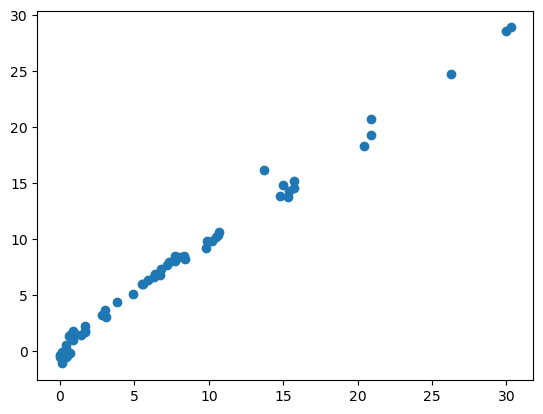

In [32]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scale,y_train)
y_pred=lassocv.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
plt.scatter(y_test,y_pred)
print("mean_absolut_error ",mae)
print("R2_score ",score)


#### Ridge cross Validation

mean_absolut_error  0.6053972973991
R2_score  0.9888919408825259


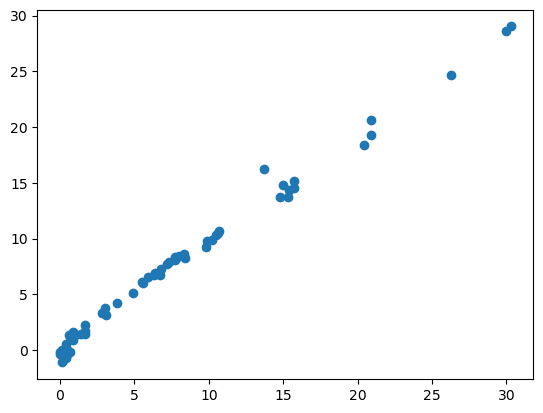

In [34]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error,r2_score
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scale,y_train)
y_pred=ridgecv.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
plt.scatter(y_test,y_pred)
print("mean_absolut_error ",mae)
print("R2_score ",score)

#### Elastic Cross Validation model hyper tunning

mean_absolut_error  1.2053069952384183
R2_score  0.9512356962114603


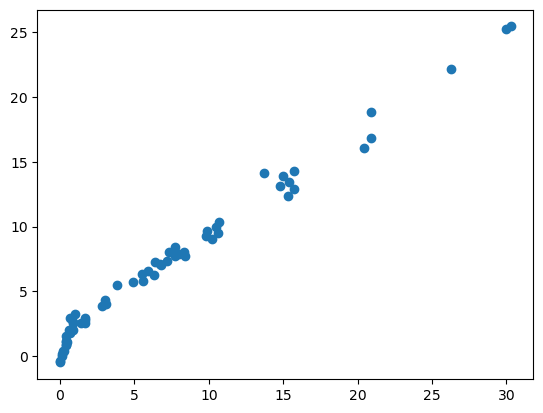

In [35]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error,r2_score
elastic_cv=ElasticNetCV(cv=5)
elastic_cv.fit(X_train_scale,y_train)
y_pred=lassoo.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
plt.scatter(y_test,y_pred)
print("mean_absolut_error ",mae)
print("R2_score ",score)

#### pickle the machine learning, preprocessing models

In [25]:
scaler


StandardScaler()

In [26]:
ridgee

Ridge()

In [39]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))

In [40]:
pickle.dump(ridgee,open('ridge.pkl','wb'))